# Atividade 03 — Regressão Linear, Resíduos, Múltipla e Bootstrap

**Script R equivalente:** [`../scriptsR/03-regressao-linear.R`](../scriptsR/03-regressao-linear.R)

**Explicação detalhada (consolidado):** [consolidado/03-regressao-linear.md](https://github.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/blob/main/consolidado/03-regressao-linear.md)

**Propósito deste notebook:** permitir a execução desta atividade no Google Colab (runtime R), exibindo todas as saídas e gráficos inline. Diferente do script `.R`, este notebook **não grava arquivos** — não salva `.png` nem relatórios `.md`.

**Alvo:** `mortalidade_60_69` (mortes por mil hab., 60–69).

**Como rodar no Colab:** `Runtime` → `Change runtime type` → selecionar **R** → `Run all`.


In [1]:
# =============================================================
# SETUP — Atividade 03
# =============================================================
# No Google Colab: Runtime > Change runtime type > R
# Esta atividade nao requer pacotes externos.

options(repr.plot.width = 7, repr.plot.height = 7)

cat("[INFO] Setup concluido.\n")

[INFO] Setup concluido.


In [2]:
# =============================================================
# DADOS — Atividade 03
# =============================================================
arquivo_local <- file.path("..", "bancoDeDados", "df_ipdm_baixada_por_municipio.csv")
url_github    <- "https://raw.githubusercontent.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/main/estrutura/bancoDeDados/df_ipdm_baixada_por_municipio.csv"

if (file.exists(arquivo_local)) {
  origem_dados <- arquivo_local
  cat("[INFO] Carregando banco LOCAL.\n")
} else {
  origem_dados <- url_github
  cat("[INFO] Carregando do GitHub.\n")
}

dados_brutos <- read.csv(origem_dados, sep = ";", dec = ",", fileEncoding = "latin1",
                         check.names = FALSE, stringsAsFactors = FALSE)

dados <- data.frame(
  ano               = as.integer(dados_brutos[[3]]),
  riqueza           = as.numeric(dados_brutos[[4]]),
  escolaridade      = as.numeric(dados_brutos[[6]]),
  mortalidade_60_69 = as.numeric(dados_brutos[[8]]),
  distorcao_em      = as.numeric(dados_brutos[[9]]),
  pib_per_capita    = as.numeric(dados_brutos[[10]])
)

y <- dados$mortalidade_60_69
x <- dados$escolaridade

cat("[INFO] Dados carregados:", nrow(dados), "linhas.\n")

[INFO] Carregando banco LOCAL.
[INFO] Dados carregados: 54 linhas.


In [3]:
# =============================================================
# ANALISE — Atividade 03
# =============================================================
# Modelo simples
m <- lm(mortalidade_60_69 ~ escolaridade, data = dados)
s <- summary(m); ci <- confint(m)
cat("\n================ MODELO SIMPLES ================\n")
printCoefmat(coef(s), signif.legend = FALSE)
b0 <- coef(m)[1]; b1 <- coef(m)[2]
cat("\nEquacao: mortalidade =", round(b0, 4), "+", round(b1, 4), "x escolaridade\n")
cat("IC 95%:\n"); print(ci)
cat("R2 =", round(s$r.squared, 4),
    "| R2 aj =", round(s$adj.r.squared, 4),
    "| RSE =", round(s$sigma, 4), "\n")
cat("Interpretacao: cada +1 em escolaridade muda a mortalidade em",
    round(b1, 4), "mortes por mil hab. (sinal",
    ifelse(b1 < 0, "negativo - mais educacao, menos mortalidade",
           "positivo"), ").\n")

esc_ex <- c(0.35, 0.45, 0.55, 0.65)
pred_ex <- predict(m, newdata = data.frame(escolaridade = esc_ex))
cat("\nPrevisoes:\n")
print(data.frame(escolaridade = esc_ex, mortalidade_prev = round(pred_ex, 3)))

shap <- shapiro.test(resid(m))
cat("\nShapiro (simples): W =", round(shap$statistic, 4),
    "| p =", round(shap$p.value, 5), "\n")

# Bootstrap
set.seed(1); B <- 2000
b1_boot <- replicate(B, {
  i <- sample(length(y), length(y), replace = TRUE)
  coef(lm(y[i] ~ x[i]))[2]
})
se_boot <- sd(b1_boot); ci_boot <- quantile(b1_boot, c(0.025, 0.975))
cat("\n================ BOOTSTRAP ================\n")
cat("b1 MQO:", sprintf("%.4f", b1), "\n")
cat("EP bootstrap:", sprintf("%.4f", se_boot), "\n")
cat("IC 95%: [", sprintf("%.4f", ci_boot[1]), ";", sprintf("%.4f", ci_boot[2]), "]\n")

# Modelo multiplo
m2 <- lm(mortalidade_60_69 ~ escolaridade + distorcao_em, data = dados)
s2 <- summary(m2)
cat("\n================ MODELO MULTIPLO ================\n")
printCoefmat(coef(s2), signif.legend = FALSE)

cat("\n================ SIMPLES vs MULTIPLA ================\n")
print(data.frame(
  Modelo = c("Simples (escolaridade)", "Multipla (+ distorcao_em)"),
  R2 = round(c(s$r.squared, s2$r.squared), 4),
  R2_aj = round(c(s$adj.r.squared, s2$adj.r.squared), 4),
  RSE = round(c(s$sigma, s2$sigma), 4),
  p = c(1, 2)
))
cor_pred <- cor(dados$escolaridade, dados$distorcao_em)
cat("Correlacao escolaridade x distorcao_em:", round(cor_pred, 4), "\n")

shap2 <- shapiro.test(resid(m2))
cat("Shapiro (multipla): W =", round(shap2$statistic, 4),
    "| p =", round(shap2$p.value, 5), "\n")


================ MODELO SIMPLES ================
             Estimate Std. Error t value  Pr(>|t|)    
(Intercept)   20.9266     4.1904  4.9940 7.034e-06 ***
escolaridade  -2.0959     8.5337 -0.2456     0.807    

Equacao: mortalidade = 20.9266 + -2.0959 x escolaridade
IC 95%:
                 2.5 %   97.5 %
(Intercept)   12.51799 29.33515
escolaridade -19.22011 15.02830
R2 = 0.0012 | R2 aj = -0.018 | RSE = 3.885 
Interpretacao: cada +1 em escolaridade muda a mortalidade em -2.0959 mortes por mil hab. (sinal negativo - mais educacao, menos mortalidade ).

Previsoes:
  escolaridade mortalidade_prev
1         0.35           20.193
2         0.45           19.983
3         0.55           19.774
4         0.65           19.564

Shapiro (simples): W = 0.9399 | p = 0.00925 

================ BOOTSTRAP ================
b1 MQO: -2.0959 
EP bootstrap: 7.9221 
IC 95%: [ -18.8741 ; 11.8109 ]

================ MODELO MULTIPLO ================
             Estimate Std. Error t value Pr(>|t|)  
(

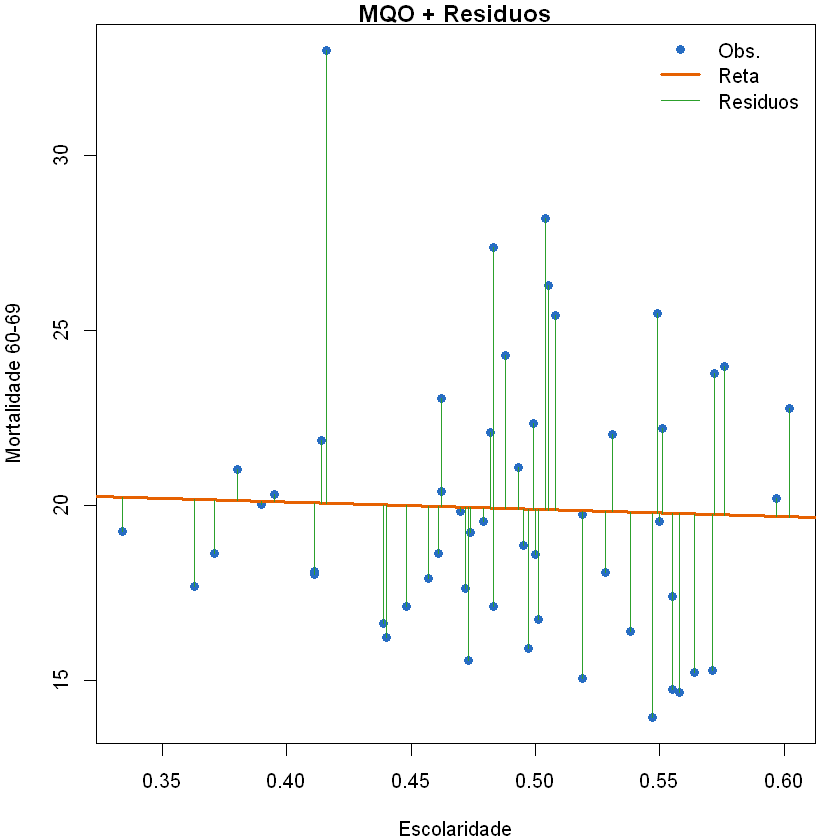

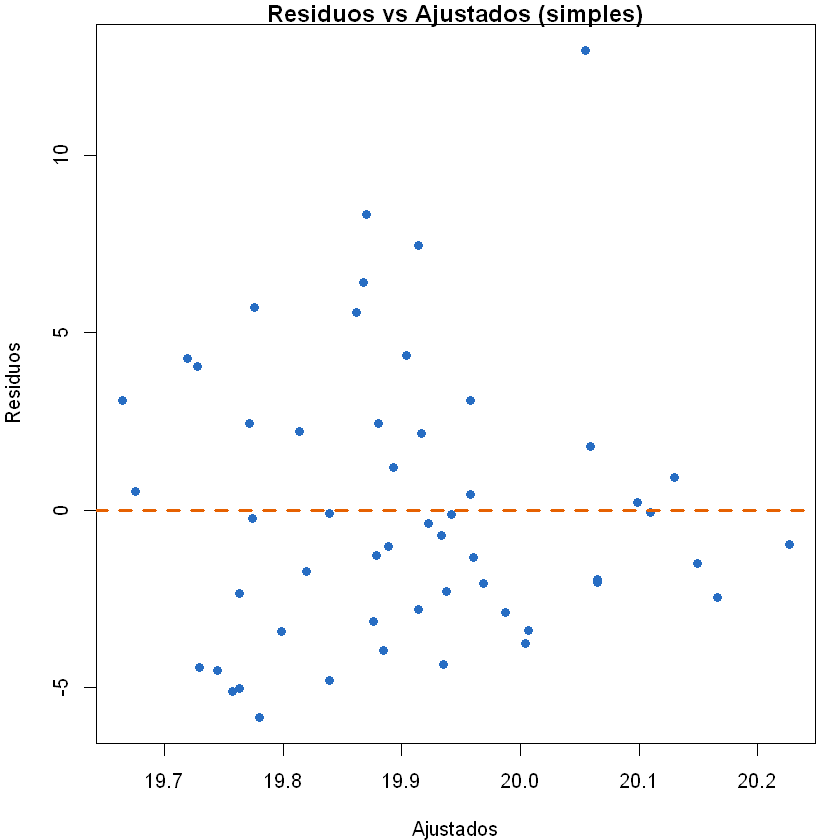

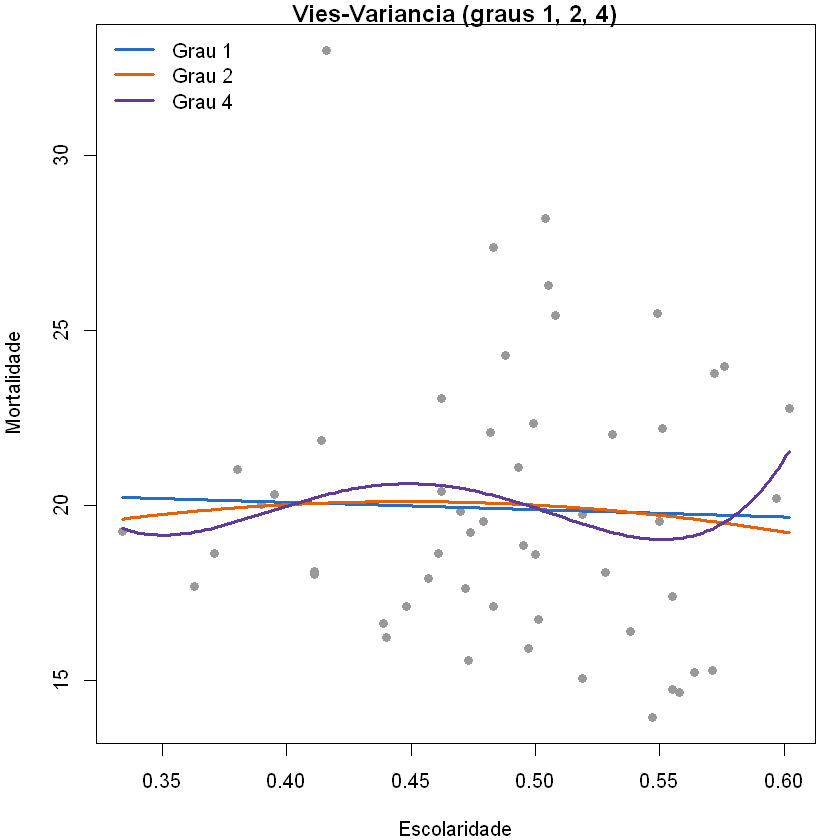

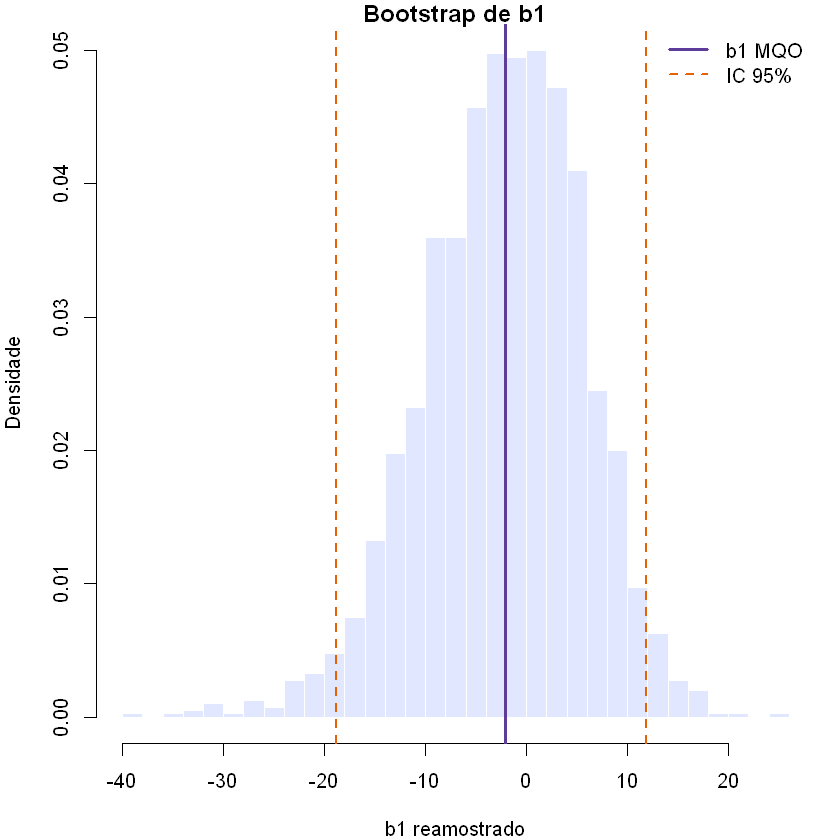

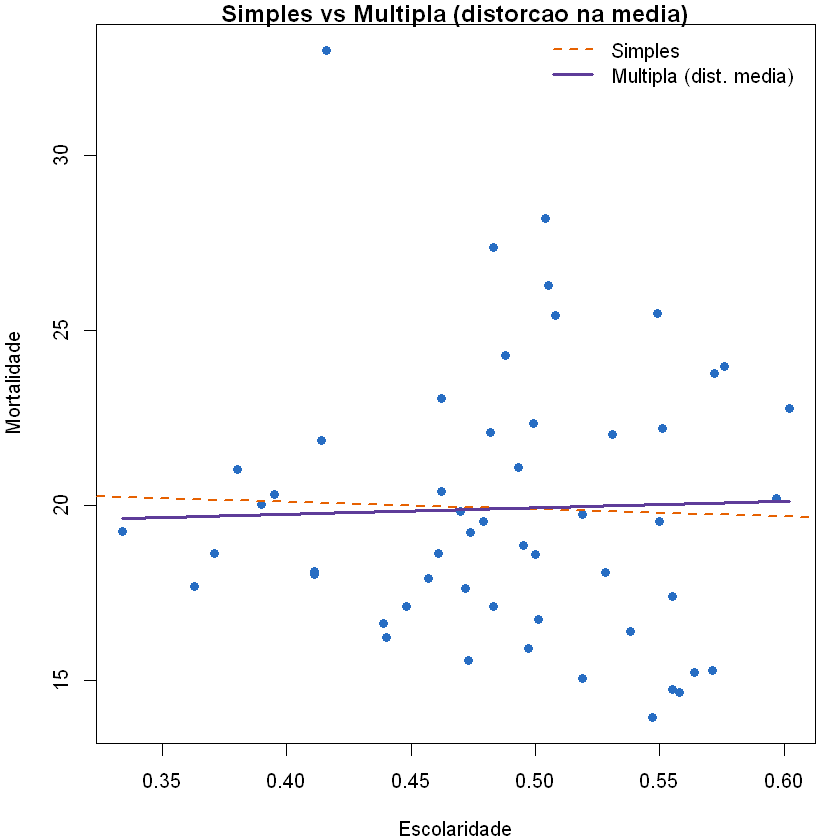

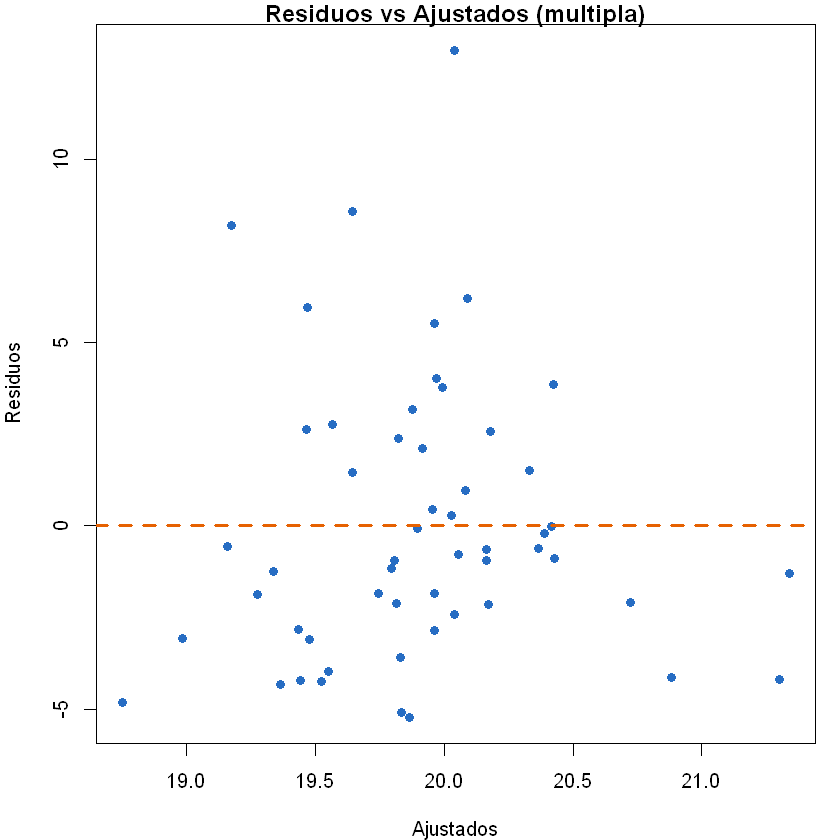

In [4]:
# =============================================================
# GRAFICOS — Atividade 03
# =============================================================
cazul <- "#276DC3"; claranja <- "#E66101"; cverde <- "#2CA02C"
croxo <- "#5E3C99"; cfill <- "#E0E7FF"

# Grafico 1 — dispersao + reta + residuos
par(mar = c(4,4,1,1), pty = "s")
plot(x, y, pch = 19, col = cazul,
     xlab = "Escolaridade", ylab = "Mortalidade 60-69", main = "MQO + Residuos")
abline(m, col = claranja, lwd = 3)
segments(x, y, x, fitted(m), col = cverde, lwd = 1.2)
legend("topright", c("Obs.","Reta","Residuos"),
       col = c(cazul,claranja,cverde), pch = c(19,NA,NA),
       lwd = c(NA,3,1.2), lty = c(NA,1,1), bty = "n")

# Grafico 2 — residuos vs ajustados (simples)
par(mar = c(4,4,1,1), pty = "s")
plot(fitted(m), resid(m), pch = 19, col = cazul,
     xlab = "Ajustados", ylab = "Residuos", main = "Residuos vs Ajustados (simples)")
abline(h = 0, col = claranja, lwd = 3, lty = 2)

# Grafico 3 — vies-variancia (graus 1, 2, 4)
par(mar = c(4,4,1,1), pty = "s")
plot(x, y, pch = 19, col = "gray60",
     xlab = "Escolaridade", ylab = "Mortalidade", main = "Vies-Variancia (graus 1, 2, 4)")
xx <- seq(min(x), max(x), length.out = 200)
cores <- c(cazul, claranja, croxo); graus <- c(1, 2, 4)
for (k in seq_along(graus)) {
  mp <- lm(y ~ poly(x, graus[k]))
  lines(xx, predict(mp, newdata = data.frame(x = xx)), col = cores[k], lwd = 2.5)
}
legend("topleft", c("Grau 1","Grau 2","Grau 4"), col = cores, lwd = 2.5, bty = "n")

# Grafico 4 — bootstrap de b1
par(mar = c(4,4,1,1), pty = "s")
hist(b1_boot, breaks = 30, prob = TRUE, col = cfill, border = "white",
     xlab = "b1 reamostrado", ylab = "Densidade", main = "Bootstrap de b1")
abline(v = ci_boot, col = claranja, lwd = 2, lty = 2)
abline(v = b1, col = croxo, lwd = 3)
legend("topright", c("b1 MQO","IC 95%"),
       col = c(croxo,claranja), lwd = c(3,2), lty = c(1,2), bty = "n")

# Grafico 5 — simples vs multipla
par(mar = c(4,4,1,1), pty = "s")
plot(dados$escolaridade, dados$mortalidade_60_69, pch = 19, col = cazul,
     xlab = "Escolaridade", ylab = "Mortalidade",
     main = "Simples vs Multipla (distorcao na media)")
grid_x <- seq(min(x), max(x), length.out = 100)
pred_m2 <- predict(m2, newdata = data.frame(
  escolaridade = grid_x,
  distorcao_em = rep(mean(dados$distorcao_em), 100)))
abline(m, col = claranja, lwd = 2, lty = 2)
lines(grid_x, pred_m2, col = croxo, lwd = 3)
legend("topright", c("Simples","Multipla (dist. media)"),
       col = c(claranja,croxo), lwd = c(2,3), lty = c(2,1), bty = "n")

# Grafico 6 — residuos vs ajustados (multipla)
par(mar = c(4,4,1,1), pty = "s")
plot(fitted(m2), resid(m2), pch = 19, col = cazul,
     xlab = "Ajustados", ylab = "Residuos", main = "Residuos vs Ajustados (multipla)")
abline(h = 0, col = claranja, lwd = 3, lty = 2)